# DATA-445 In-Class Assignment 3

Consider the `framingham.csv` data file. The dataset is publicly available on the Kaggle website, and it is from an ongoing cardiovascular study on residents of the town of Framingham, Massachusetts. The classification goal is to predict whether the patient has 10-year risk of future coronary heart disease (CHD). The dataset provides the patients' information. It includes over 4,000 records and 15 attributes. Each attribute is a potential risk factor. There are demographic, behavioral, and medical risk factors.

- **Demographic:**
  - Sex: male or female (Nominal)
  - Age: Age of the patient (Continuous)
- **Behavioral:**
  - Current Smoker: whether or not the patient is a current smoker (Nominal)
  - Cigs Per Day: the number of cigarettes that the person smoked on average in one day (Continuous)
- **Medical (history):**
  - BP Meds: whether or not the patient was on blood pressure medication (Nominal)
  - Prevalent Stroke: whether or not the patient had previously had a stroke (Nominal)
  - Prevalent Hyp: whether or not the patient was hypertensive (Nominal)
  - Diabetes: whether or not the patient had diabetes (Nominal)
- **Medical (current):**
  - Tot Chol: total cholesterol level (Continuous)
  - Sys BP: systolic blood pressure (Continuous)
  - Dia BP: diastolic blood pressure (Continuous)
  - BMI: Body Mass Index (Continuous)
  - Heart Rate: heart rate (Continuous)
  - Glucose: glucose level (Continuous)
- **Predict variable (desired target):**
  - 10 year risk of coronary heart disease CHD (binary: "1" means "Yes", "0" means "No")

## 1. (3 points) Using the pandas library, read the csv data file and create a data-frame called `heart`.

In [2]:
import pandas as pd

heart = pd.read_csv('framingham.csv')
heart.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [4]:
heart.info()

<class 'pandas.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4238 non-null   int64  
 1   age              4238 non-null   int64  
 2   education        4133 non-null   float64
 3   currentSmoker    4238 non-null   int64  
 4   cigsPerDay       4209 non-null   float64
 5   BPMeds           4185 non-null   float64
 6   prevalentStroke  4238 non-null   int64  
 7   prevalentHyp     4238 non-null   int64  
 8   diabetes         4238 non-null   int64  
 9   totChol          4188 non-null   float64
 10  sysBP            4238 non-null   float64
 11  diaBP            4238 non-null   float64
 12  BMI              4219 non-null   float64
 13  heartRate        4237 non-null   float64
 14  glucose          3850 non-null   float64
 15  TenYearCHD       4238 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 529.9 KB


In [5]:
heart.isnull().sum()

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

## 2. (3 points) Remove observations with missing values.

In [8]:
heart = heart.dropna()
heart.shape

(3656, 16)

## 3. (4 points) Create a scatter plot of `BMI` and `heartRate`. Describe the plot.

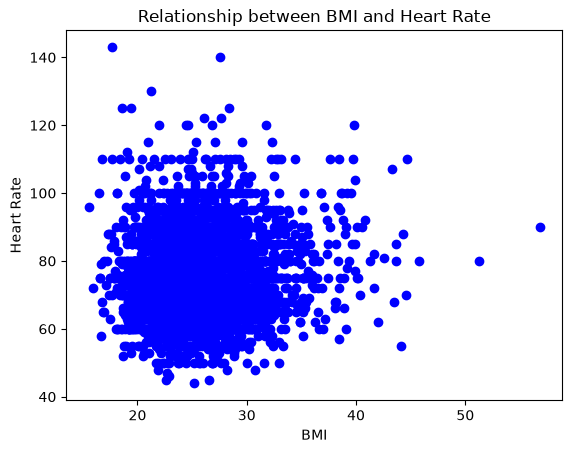

In [9]:
import matplotlib.pyplot as plt
plt.plot(heart['BMI'], heart['heartRate'], 'o', color='blue')
plt.xlabel('BMI')
plt.ylabel('Heart Rate')
plt.title('Relationship between BMI and Heart Rate')
plt.show()

From the scatter plot above, we dont see any specific relationship between BMI and heartrate

## 4. (4 points) Create a scatter plot of `glucose` and `BMI`. Describe the plot.

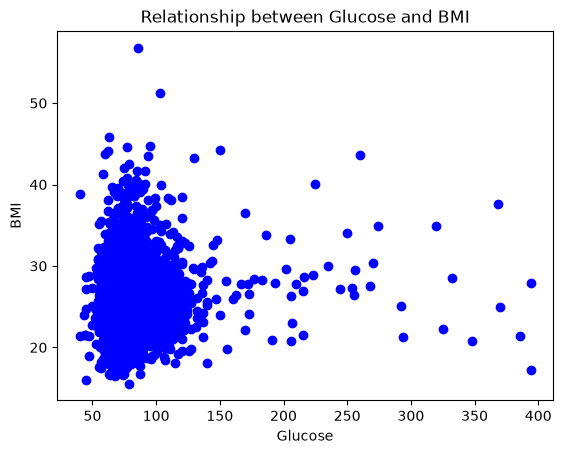

In [11]:
plt.plot(heart['glucose'], heart['BMI'], 'o', color='blue')
plt.xlabel('Glucose')
plt.ylabel('BMI')
plt.title('Relationship between Glucose and BMI')
plt.show()

From the scatter plot above, we dont see any specific relationship between BMI and glucose

## 5. (5 points) Build a logistic regression model in which: `age`, `currentSmoker`, `totChol`, `BMI`, and `heartRate` are the predictor variables, and `TenYearCHD` is the target variable.

In [16]:
from sklearn.linear_model import LogisticRegression

X = heart[['age','currentSmoker','totChol','BMI','heartRate']]
Y = heart['TenYearCHD']

model = LogisticRegression()
model.fit(X,Y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

## 6. (3 points) Using the model from part 5, predict the likelihood of risk of coronary disease of a patient with the following characteristics: `age = 50`, `currentSmoker = 1`, `totChol = 250`, `BMI = 27`, and `heartRate = 85`.

In [17]:
new_df = pd.DataFrame({
    'age': [50],
    'currentSmoker': [1],
    'totChol': [250],
    'BMI': [27],
    'heartRate': [85]
})

# predicting the likelihood of developing heart disease in the next 10 years for the new data point
prediction = model.predict_proba(new_df)
prediction

array([[0.81930797, 0.18069203]])